# Упражнение 4.9. Итерация по ценности: задача об азартном игроке

Саттон, Барто, «Обучение с подкреплением».
Полный разбор — в сборнике решений: [глава 4 (PDF)](https://michaeltoschenko.github.io/RL_Sutton_Barto_Solutions/ch04.pdf).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [108]:
tetta = 1e-15
goal = 100

In [121]:
def run_value_iteration_player_problem(ph=0.4, eps = 1e-12):
    value = np.zeros(goal+1)
    value[goal] = 1
    
    delta = float('inf')
    while delta > tetta:
        delta = 0
        for s in range(1, goal):
            v_old = value[s]
            actions = np.arange(1, min(s, goal-s)+1)
            cur_values = ph*value[s+actions] + (1-ph)*value[s-actions]
            value[s] = cur_values.max()
            delta = max(delta, abs(v_old - value[s]))
    
     # множество оптимальных действий
    A_star = [None] * (goal + 1)
    pi = np.zeros(goal + 1, dtype=int)
    for s in range(1, goal):
        actions = np.arange(1, min(s, goal - s) + 1)
        q = ph * value[s + actions] + (1 - ph) * value[s - actions]
        qmax = q.max()
        opt_actions = actions[(qmax - q) <= eps]
        A_star[s] = opt_actions.tolist()

        # выбираем один представитель (например, минимальный)
        pi[s] = int(opt_actions.min())

    A_star[0] = []
    A_star[goal] = []
    return value, pi, A_star

In [122]:
v_original, pi_original, _ = run_value_iteration_player_problem()
v_25, pi_25, _ = run_value_iteration_player_problem(ph=0.25)
v_55, pi_55, _ = run_value_iteration_player_problem(ph=0.55)

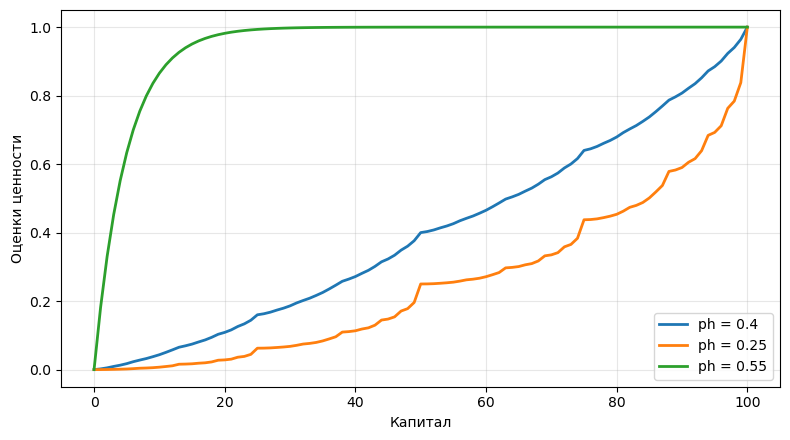

In [123]:
x = np.arange(goal+1) 

plt.figure(figsize=(8, 4.5))

plt.plot(x, v_original, linewidth=2, label=f'ph = {0.4}')
plt.plot(x, v_25, linewidth=2, label=f'ph = {0.25}')
plt.plot(x, v_55, linewidth=2, label=f'ph = {0.55}')

plt.xlabel('Капитал')
plt.ylabel('Оценки ценности')

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

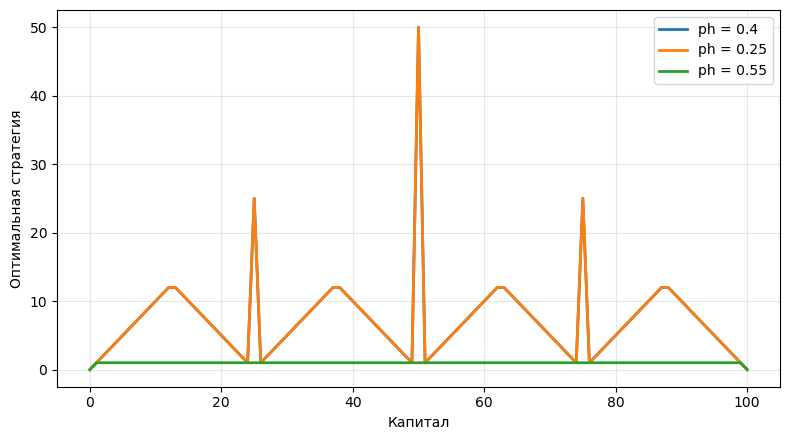

In [125]:
x = np.arange(goal+1) 

plt.figure(figsize=(8, 4.5))

plt.plot(x, pi_original, linewidth=2, label=f'ph = {0.4}')
plt.plot(x, pi_25, linewidth=2, label=f'ph = {0.25}')
plt.plot(x, pi_55, linewidth=2, label=f'ph = {0.55}')

plt.xlabel('Капитал')
plt.ylabel('Оптимальная стратегия')

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()